# SINDy with constraints

In [ ]:
"""
Hodgkin-Huxley Model identification
Mariana, Bernardo, March 2026
"""

import math
from re import L
import re
import numpy as np
import pysindy as ps
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import scienceplots
plt.style.use(['science'])

import random

np.random.seed(seed=10)
noise1 = np.random.normal(0, 1, size=10)

## Synthetic data

In [2]:
def alpha_m(V):
    return 0.1 * (V + 40) / (1 - np.exp(-(V + 40) / 10))

def beta_m(V):
    return 4.0 * np.exp(-0.0556 * (V + 65))

def alpha_h(V):
    return 0.07 * np.exp(-0.05 * (V + 65))

def beta_h(V):
    return 1 / (1 + np.exp(-(V + 35) / 10))

def alpha_n(V):
    return 0.01 * (V + 55) / (1 - np.exp(-(V + 55) / 10))

def beta_n(V):
    return 0.125 * np.exp(-0.0125 * (V + 65))

def hh_model(y, I):
    V, m, h, n = y
    
    C_m  = 1.0
    g_Na = 120.0
    g_K  = 36.0
    g_L  = 0.3
    E_Na = 50.0
    E_K  = -77.0
    E_L  = -54.4
    
    dVdt = (I - g_Na * m**3 * h * (V - E_Na) - g_K * n**4 * (V - E_K) - g_L * (V - E_L)) / C_m
    dmdt = alpha_m(V) * (1 - m) - beta_m(V) * m
    dhdt = alpha_h(V) * (1 - h) - beta_h(V) * h
    dndt = alpha_n(V) * (1 - n) - beta_n(V) * n
    
    return np.array([dVdt, dmdt, dhdt, dndt])

dt      = 0.05
t_final = 100
n_steps = int(t_final / dt)

t   = np.arange(0, t_final, dt)
V   = np.zeros(n_steps)
m   = np.zeros(n_steps)
h   = np.zeros(n_steps)
n   = np.zeros(n_steps)
dV  = np.zeros(n_steps)
dm  = np.zeros(n_steps)
dh  = np.zeros(n_steps)
dn  = np.zeros(n_steps)

# -63.74660111687549,
# 0.0579677361572967,
# 0.45181238339387086,
# 0.3986286597964018

V[0]    = -60.47271020589096
m[0]    = 0.0840395577340696
h[0]    = 0.4589340518422895
n[0]    = 0.3890302094251769
I       = 10.0  

for i in range(1, n_steps):
    dydt = hh_model([V[i-1], m[i-1], h[i-1], n[i-1]], I)
    V[i] = V[i-1] + dt * dydt[0]
    m[i] = m[i-1] + dt * dydt[1]
    h[i] = h[i-1] + dt * dydt[2]
    n[i] = n[i-1] + dt * dydt[3]
    dV[i], dm[i], dh[i], dn[i] = dydt
    


In [3]:
data = np.transpose([t, V, m, h, n, dV, dm, dh, dn])
np.savetxt('hh-data.txt', data)

In [4]:
V[-1], m[-1], h[-1], n[-1]

(np.float64(-64.97031344416547),
 np.float64(0.05025318463310694),
 np.float64(0.4425709180282641),
 np.float64(0.4072075293229723))

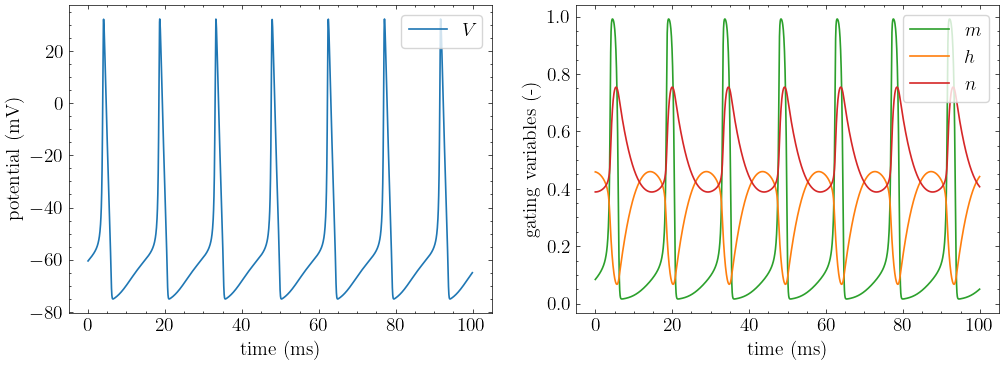

In [5]:
plt.figure(figsize=(12, 4))
plt.rc('font', size=14)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_iter = iter(colors)

c0 = next(color_iter)
c1 = next(color_iter)
c2 = next(color_iter)
c3 = next(color_iter)
# c4 = next(color_iter)

plt.subplot(1, 2, 1)
plt.plot(t, V, '-', color='tab:blue', label="$V$", linewidth=1.2, alpha=1.0)
plt.legend(loc='upper right', frameon=True, framealpha=0.8, fancybox=True)
plt.ylabel('potential (mV)')
plt.xlabel('time (ms)')

plt.subplot(1, 2, 2)
plt.plot(t, m, '-', color='tab:green', label="$m$", linewidth=1.2, alpha=1.0)
plt.plot(t, h, '-', color='tab:orange', label="$h$", linewidth=1.2, alpha=1.0)
plt.plot(t, n, '-', color='tab:red', label="$n$", linewidth=1.2, alpha=1.0)
plt.ylabel('gating variables (-)')
plt.xlabel('time (ms)')
plt.legend(loc='upper right', frameon=True, framealpha=0.8, fancybox=True)
plt.savefig('hh_model.pdf', dpi=300)
plt.show()

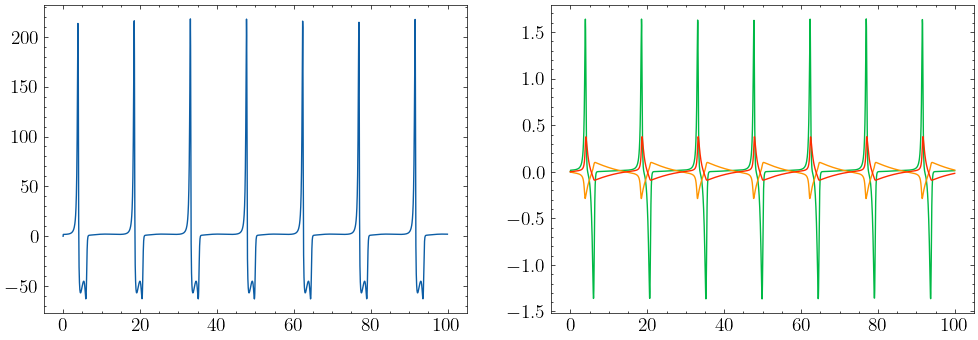

In [6]:
plt.figure(figsize=(12, 4))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_iter = iter(colors)

plt.subplot(1, 2, 1)
plt.plot(t, dV, color=next(color_iter))
# plt.ylabel('dV/dt (mV/ms)')

plt.subplot(1, 2, 2)
plt.plot(t, dm, color=next(color_iter))
plt.plot(t, dh, color=next(color_iter))
plt.plot(t, dn, color=next(color_iter))

plt.show()

## SINDy

Loading data

In [7]:
data = np.loadtxt('hh-data.txt')

t_data  = data[0:, 0]
v_data  = data[0:, 1]
m_data  = data[0:, 2]
h_data  = data[0:, 3]
n_data  = data[0:, 4]

scaler = MinMaxScaler()

noise_amplitude = 1.0  # Adjust as needed (e.g., 0.5 mV)
noise1 = np.random.normal(0, noise_amplitude, size=v_data.shape)

noise_amplitude = 0.01  # Adjust as needed (e.g., 0.5 mV)
noise2 = np.random.normal(0, noise_amplitude, size=v_data.shape)

# Add noise to membrane potential
v_data = v_data + noise1
m_data = m_data + noise2
h_data = h_data + noise2
n_data = n_data + noise2

X = np.zeros((len(t_data), 4))
X[:, 0] = v_data
X[:, 1] = m_data
X[:, 2] = h_data
X[:, 3] = n_data
dt = t_data[1] - t_data[0]

print(X)

[[-6.00396840e+01  8.36356111e-02  4.58530105e-01  3.88626263e-01]
 [-5.91794362e+01  7.86545344e-02  4.52563292e-01  3.82812637e-01]
 [-6.12571710e+01  7.04270468e-02  4.43322964e-01  3.73759218e-01]
 ...
 [-6.45045200e+01  5.35209246e-02  4.45163788e-01  4.13364685e-01]
 [-6.40644987e+01  5.99376851e-02  4.51933348e-01  4.18328555e-01]
 [-6.31672996e+01  2.61119185e-02  4.18429652e-01  3.83066263e-01]]


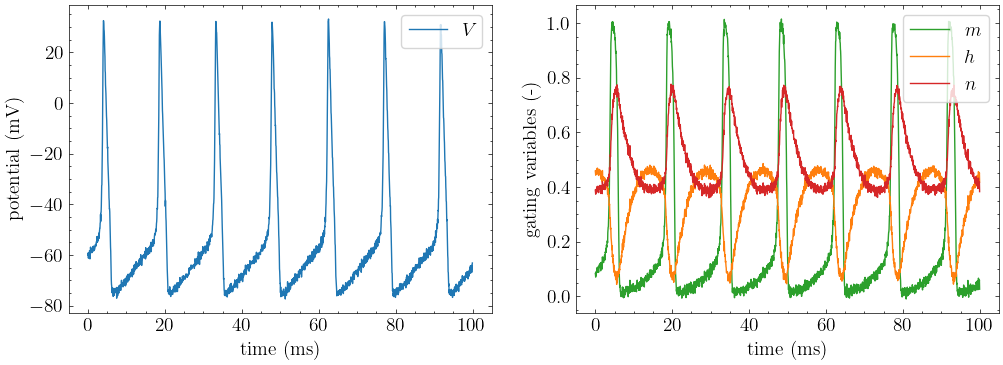

In [8]:
plt.figure(figsize=(12, 4))
plt.rc('font', size=14)

# colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
# color_iter = iter(colors)

plt.subplot(1, 2, 1)
plt.plot(t_data, X[:, 0], '-', color='tab:blue', label="$V$", linewidth=1.0, alpha=1.0)
plt.legend(loc='upper right', frameon=True, framealpha=0.8, fancybox=True)
plt.ylabel('potential (mV)')
plt.xlabel("time (ms)")

plt.subplot(1, 2, 2)
plt.plot(t_data, X[:, 1], '-', color='tab:green', label="$m$", linewidth=1.0, alpha=1.0)
plt.plot(t_data, X[:, 2], '-', color='tab:orange', label="$h$", linewidth=1.0, alpha=1.0)
plt.plot(t_data, X[:, 3], '-', color='tab:red', label="$n$", linewidth=1.0, alpha=1.0)
plt.ylabel('gating variables (-)')
plt.xlabel("time (ms)")
plt.legend(loc='upper right', frameon=True, framealpha=0.8, fancybox=True)
plt.savefig("noisy-data.pdf", dpi=300)
plt.show()

Lambda range

In [9]:
nth     = 3
a, b    = 0.47, 0.49
thr     = np.linspace(a, b, nth)
nth     = len(thr)

thr

array([0.47, 0.48, 0.49])

Constrained SR3

In [10]:
library = ps.PolynomialLibrary(degree=5)
opt = ps.SR3(threshold=0.1)
model = ps.SINDy(
    differentiation_method=ps.SINDyDerivative(),
    feature_library=library,
    optimizer=opt,
    feature_names=["v", "m", "h", "n"]
)

model.fit(X, t=t_data)
model.print()

(v)' = 13554.970 1 + -2560.936 v + 137864.767 m + -71785.898 h + -260619.896 n + -1.137 v^2 + 293.655 v m + 10025.988 v h + 4062.164 v n + 196548.603 m^2 + -432924.267 m h + -2965.592 m n + -130442.310 h^2 + 771123.263 h n + 152419.242 n^2 + 26.578 v^2 m + -79.397 v^2 h + -86.245 v^2 n + 1640.462 v m^2 + 9315.278 v m h + 11124.606 v m n + -25372.184 v h^2 + -22474.693 v h n + -15664.620 v n^2 + -434261.814 m^3 + -382227.830 m^2 h + -168871.280 m^2 n + 209685.030 m h^2 + 259127.560 m h n + -121247.867 m n^2 + 463967.818 h^3 + -335448.320 h^2 n + 212550.506 h n^2 + 28376.924 n^3 + -0.510 v^3 h + -0.276 v^3 n + 19.884 v^2 m^2 + 90.442 v^2 m h + -19.809 v^2 m n + 89.728 v^2 h^2 + 311.504 v^2 h n + 77.316 v^2 n^2 + -4456.079 v m^3 + -13481.141 v m^2 h + 2182.102 v m^2 n + -7950.418 v m h^2 + -30647.984 v m h n + -14161.766 v m n^2 + 28323.333 v h^3 + 50965.868 v h^2 n + 59073.831 v h n^2 + 18455.201 v n^3 + 152119.182 m^4 + 689519.490 m^3 h + 505075.708 m^3 n + -744166.491 m^2 h^2 + -71476.

/home/mariana/anaconda3/lib/python3.13/site-packages/pysindy/optimizers/sr3.py:390: ConvergenceWarning: SR3._reduce did not converge after 30 iterations.
  warnings.warn(


Feature library

In [11]:
terms = model.feature_library.get_feature_names()
for t in terms:
    print(t, end=" "),

1 x0 x1 x2 x3 x0^2 x0 x1 x0 x2 x0 x3 x1^2 x1 x2 x1 x3 x2^2 x2 x3 x3^2 x0^3 x0^2 x1 x0^2 x2 x0^2 x3 x0 x1^2 x0 x1 x2 x0 x1 x3 x0 x2^2 x0 x2 x3 x0 x3^2 x1^3 x1^2 x2 x1^2 x3 x1 x2^2 x1 x2 x3 x1 x3^2 x2^3 x2^2 x3 x2 x3^2 x3^3 x0^4 x0^3 x1 x0^3 x2 x0^3 x3 x0^2 x1^2 x0^2 x1 x2 x0^2 x1 x3 x0^2 x2^2 x0^2 x2 x3 x0^2 x3^2 x0 x1^3 x0 x1^2 x2 x0 x1^2 x3 x0 x1 x2^2 x0 x1 x2 x3 x0 x1 x3^2 x0 x2^3 x0 x2^2 x3 x0 x2 x3^2 x0 x3^3 x1^4 x1^3 x2 x1^3 x3 x1^2 x2^2 x1^2 x2 x3 x1^2 x3^2 x1 x2^3 x1 x2^2 x3 x1 x2 x3^2 x1 x3^3 x2^4 x2^3 x3 x2^2 x3^2 x2 x3^3 x3^4 x0^5 x0^4 x1 x0^4 x2 x0^4 x3 x0^3 x1^2 x0^3 x1 x2 x0^3 x1 x3 x0^3 x2^2 x0^3 x2 x3 x0^3 x3^2 x0^2 x1^3 x0^2 x1^2 x2 x0^2 x1^2 x3 x0^2 x1 x2^2 x0^2 x1 x2 x3 x0^2 x1 x3^2 x0^2 x2^3 x0^2 x2^2 x3 x0^2 x2 x3^2 x0^2 x3^3 x0 x1^4 x0 x1^3 x2 x0 x1^3 x3 x0 x1^2 x2^2 x0 x1^2 x2 x3 x0 x1^2 x3^2 x0 x1 x2^3 x0 x1 x2^2 x3 x0 x1 x2 x3^2 x0 x1 x3^3 x0 x2^4 x0 x2^3 x3 x0 x2^2 x3^2 x0 x2 x3^3 x0 x3^4 x1^5 x1^4 x2 x1^4 x3 x1^3 x2^2 x1^3 x2 x3 x1^3 x3^2 x1^2 x2^3 x1^2 x2^2 x

Setting retrictions

Note: Indexes refer to **permitted terms**

In [12]:
n_features = len(library.get_feature_names())
print(n_features)

n_equations = 4

constraints = [
    [0, 1, 56, 69, 91, 104], # eq 1
    [0, 1, 2, 5, 6, 15, 16], # eq 2
    [0, 1, 3, 5, 7, 15, 17], # eq 3
    [0, 1, 4, 5, 8, 15, 18]  # eq 4
]
print(constraints[1:])
tam_eqs234 = sum(n_features - len(c) for c in constraints[1:])

n_constraints = n_features  + tam_eqs234 # todos da eq1 e os demais das eq 2,3,4
n_terms = n_equations * n_features

print(f'numero de equacoes: {n_equations}')
print(f'numero de features por equacao: {n_features}')
print(f'total de termos: {n_terms}')
print(f'numero de restricoes: {n_constraints}' )

constraint_lhs = np.zeros((n_constraints, n_terms))
constraint_rhs = np.zeros((n_constraints))

C_m     = 1.0       # Capacitância da membrana (uF/cm^2)
g_Na    = 120.0     # Condutância máxima de sódio (mS/cm^2)
g_K     = 36.0      # Condutância máxima de potássio (mS/cm^2)
g_L     = 0.3       # Condutância de fuga (mS/cm^2)
E_Na    = 50.0      # Potencial de reversão de sódio (mV)
E_K     = -77.0     # Potencial de reversão de potássio (mV)
E_L     = -54.4     # Potencial de reversão de fuga (mV)
Iext    = 10.0

# da eq 1
constraint_rhs[0] = Iext + g_L*E_L
constraint_rhs[1] = -g_L
constraint_rhs[2] = g_Na*E_Na
constraint_rhs[3] = g_K*E_K
constraint_rhs[4] = -g_Na
constraint_rhs[5] = -g_K

#dVdt    = (I - g_Na * m**3 * h * (V - E_Na) - g_K * n**4 * (V - E_K) - g_L * (V - E_L)) / C_m

print(constraint_rhs)

# Constructing the constraint matrix
row = 0   
for eq_idx, eq_constraints in enumerate(constraints):
    if(eq_idx==0):
        allowed_indices = constraints[0]
        for col in allowed_indices:
            constraint_lhs[row, col + eq_idx * n_features] = 1
            row += 1       
    allowed_indices = np.setdiff1d(np.arange(n_features), eq_constraints)
    for col in allowed_indices:
        constraint_lhs[row, col + eq_idx * n_features] = 1
        row += 1   

def find_zero_rows(matrix):
    zero_rows = []
    for i, row in enumerate(matrix):
        if np.all(row == 0):
            zero_rows.append(i)
    return zero_rows

r = find_zero_rows(constraint_lhs)
print(r)
constraint_lhs

126
[[0, 1, 2, 5, 6, 15, 16], [0, 1, 3, 5, 7, 15, 17], [0, 1, 4, 5, 8, 15, 18]]
numero de equacoes: 4
numero de features por equacao: 126
total de termos: 504
numero de restricoes: 483
[-6.320e+00 -3.000e-01  6.000e+03 -2.772e+03 -1.200e+02 -3.600e+01
  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
  0.000e+00

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

Model identification

In [13]:
print('SINDy-SR3 for lambda: [%f, %f]' % (thr[0], thr[-1]))

models = []

for i in range(nth):
    th = thr[i]
    print('\nlambda = ', th)

    opt = ps.ConstrainedSR3(
    constraint_rhs=constraint_rhs,
    constraint_lhs=constraint_lhs,
    max_iter=100000,
    threshold=th,
    thresholder='l2',
    tol=1e-5,
    inequality_constraints=False
    )

    model = ps.SINDy(
        differentiation_method=ps.SINDyDerivative(),
        feature_library=library,
        optimizer=opt,
        feature_names=["v", "m", "h", "n"]
    )

    model.fit(X, t=t_data)
    model.print(precision=6)

    mse = model.score(X, t=t_data, metric=mean_squared_error)
    r2c = model.score(X, t=t_data)
    
    models.append(model)

SINDy-SR3 for lambda: [0.470000, 0.490000]

lambda =  0.47
(v)' = -5.940799 1 + -0.281997 v + -0.000001 m + -0.000001 h + -0.000005 v^2 + -0.000002 v h + -0.000002 v n + -0.000001 m^2 + 0.000001 m h + -0.000001 m n + 0.000001 h n + 0.000006 v^2 m + 0.000012 v^2 h + 0.000010 v^2 n + -0.000003 v m^2 + -0.000002 v m n + -0.000001 v h^2 + -0.000001 v h n + -0.000001 v n^2 + -0.000001 m^3 + 0.000001 m^2 h + -0.000001 m n^2 + -0.000001 n^3 + -0.000012 v^2 m h + -0.000015 v^2 m n + -0.000009 v^2 h^2 + -0.000010 v^2 h n + -0.000003 v m^3 + -0.000001 v m^2 h + -0.000001 v m^2 n + -0.000001 v m h^2 + -0.000001 v m n^2 + -0.000002 v h^3 + -0.000001 v h^2 n + 0.000001 v n^3 + 5640.000000 m^3 h + -2605.680000 n^4 + 0.000007 v^2 m h^2 + 0.000016 v^2 m h n + 0.000010 v^2 m n^2 + 0.000001 v^2 h^3 + -0.000002 v^2 h^2 n + -0.000008 v^2 h n^2 + -0.000005 v^2 n^3 + 0.000001 v m^4 + -112.799997 v m^3 h + 0.000003 v m^3 n + 0.000002 v m^2 h n + 0.000004 v m^2 n^2 + -0.000001 v m h^3 + 0.000002 v m h n^2 + 0

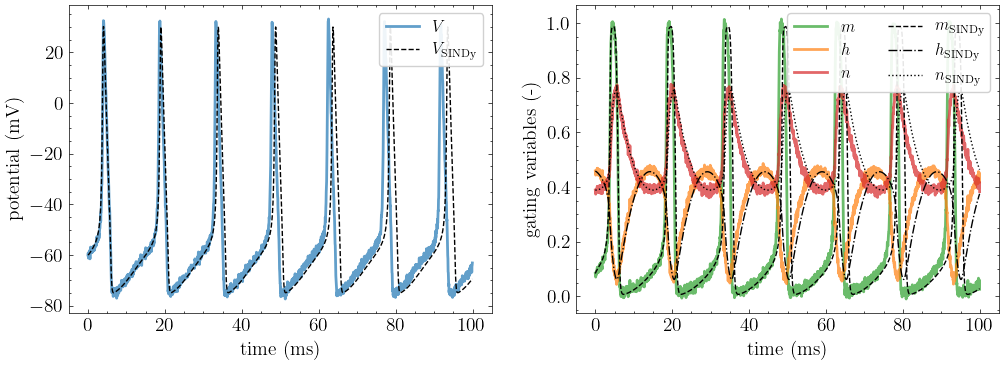

lambda = 0.47000


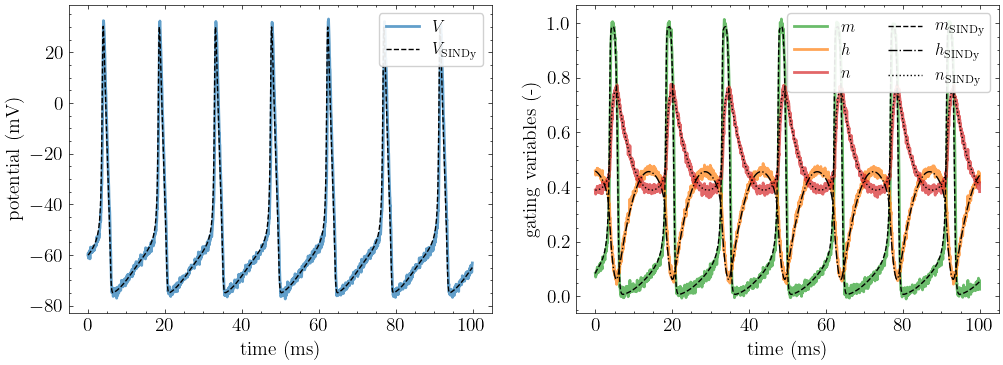

lambda = 0.48000


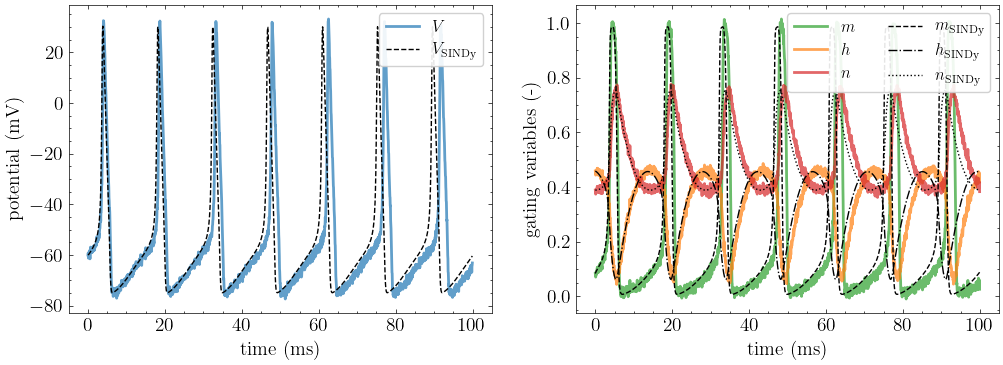

lambda = 0.49000


In [14]:
for idx in range(nth):
    mymodel = models[idx]
    sim = mymodel.simulate([v_data[0], m_data[0], h_data[0], n_data[0]], t=t_data) 
    
    plt.figure(figsize=(12, 4))
    
    # colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    # color_iter = iter(colors)

    plt.subplot(1, 2, 1)
    plt.plot(t_data, v_data, '-', color='tab:blue', label="$V$", linewidth=2.0, alpha=0.7)
    plt.plot(t_data, sim[:, 0], '--', color='black', label="$V_{\mathrm{SINDy}}$", linewidth=1.0)
    plt.legend(loc='upper right', frameon=True, framealpha=0.9, fancybox=True, fontsize=12)
    plt.ylabel('potential (mV)')
    plt.xlabel('time (ms)')
    
    plt.subplot(1, 2, 2)
    plt.plot(t_data, m_data, '-', color='tab:green', label="$m$", linewidth=2.0, alpha=0.7)
    plt.plot(t_data, h_data, '-', color='tab:orange', label="$h$", linewidth=2.0, alpha=0.7)
    plt.plot(t_data, n_data, '-', color='tab:red', label="$n$", linewidth=2.0, alpha=0.7)
    plt.plot(t_data, sim[:, 1], '--', color='black', label="$m_{\mathrm{SINDy}}$", linewidth=1.0)
    plt.plot(t_data, sim[:, 2], '-.', color='black', label="$h_{\mathrm{SINDy}}$", linewidth=1.0)
    plt.plot(t_data, sim[:, 3], ':',  color='black', label="$n_{\mathrm{SINDy}}$", linewidth=1.0)
    plt.ylabel('gating variables (-)')
    plt.xlabel('time (ms)')
    plt.legend(loc='upper right', frameon=True, framealpha=0.9, fancybox=True, ncol=2, fontsize=12)
    
    plt.show()
    print(f'lambda = {thr[idx]:.5f}')

Symbolic reconstruction

In [15]:
def format_term(name):
    name = name.replace('^', '**')
    name = re.sub(r'(?<=[a-zA-Z0-9]) (?=[a-zA-Z(])', '*', name)
    return name

threshold = 1e-8

for idx, model in enumerate(models):
    print(f'\nlambda = {thr[idx]:.5f}')
    coeffs = model.coefficients()
    feature_names = model.get_feature_names()

    for eq_idx, eq in enumerate(coeffs):
        terms = []
        for coeff, name in zip(eq, feature_names):
            if abs(coeff) > threshold:
                term = f"{coeff:.8e}*{format_term(name)}"
                terms.append(term)
        equation_str = " + ".join(terms) if terms else "0"
        print(f"dx{eq_idx}/dt = {equation_str}")


lambda = 0.47000
dx0/dt = -5.94079912e+00*1 + -2.81996685e-01*v + -9.59348981e-07*m + -8.68932111e-07*h + 3.26102600e-08*n + -4.96745975e-06*v**2 + 3.61763232e-07*v*m + -1.98523165e-06*v*h + -2.11325154e-06*v*n + -9.78177850e-07*m**2 + 1.20069089e-06*m*h + -5.12517290e-07*m*n + 1.88254489e-08*h**2 + 5.96183672e-07*h*n + -2.05777033e-07*n**2 + -8.84009569e-08*v**3 + 5.75587503e-06*v**2*m + 1.21592365e-05*v**2*h + 9.90476459e-06*v**2*n + -2.94616053e-06*v*m**2 + -2.64807895e-07*v*m*h + -2.06681201e-06*v*m*n + -9.74942814e-07*v*h**2 + -1.11751695e-06*v*h*n + -1.07735941e-06*v*n**2 + -7.70232728e-07*m**3 + 8.83951434e-07*m**2*h + -4.05068604e-07*m**2*n + 2.20591173e-07*m*h**2 + 3.86884349e-07*m*h*n + -5.42892776e-07*m*n**2 + 2.76756327e-08*h**3 + 6.56565317e-08*h**2*n + 4.71426174e-07*h*n**2 + -5.82851972e-07*n**3 + 1.98304560e-07*v**3*h + 2.32774710e-07*v**3*n + 1.19415927e-08*v**2*m**2 + -1.19175727e-05*v**2*m*h + -1.54623517e-05*v**2*m*n + -8.63196590e-06*v**2*h**2 + -9.91702080e-06*v*